In [31]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

HELPER_DIR = Path.cwd()
if not (HELPER_DIR / "multichannel_signal_tools.py").exists():
    HELPER_DIR = HELPER_DIR / "data_processing"
if str(HELPER_DIR) not in sys.path:
    sys.path.append(str(HELPER_DIR))

from multichannel_signal_tools import filter_time_range, load_multichannel_csv, plot_multichannel_overview, save_cut_csv

local_path = r"C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\1-2. [Lead] Triboresistive sensor\1. [Lead] DC TRS\1. ????\260811_contact DC3 ????\0minimized_csv??\3._6cell.csv"


max value: 1.3747


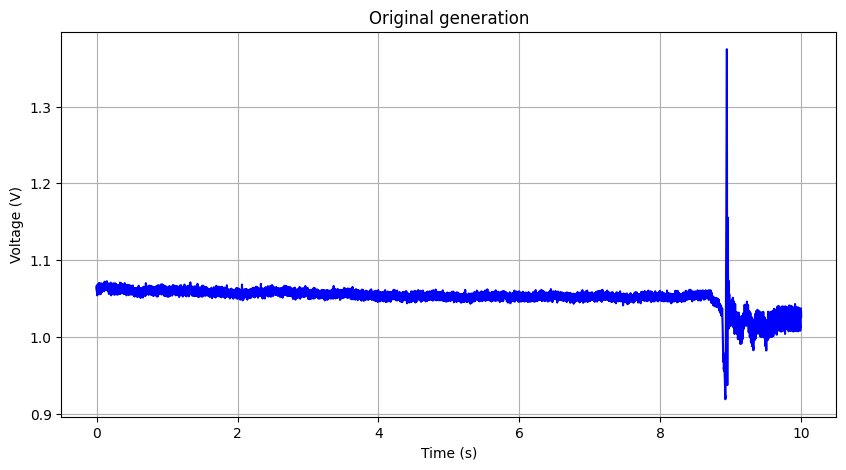

In [32]:
df = load_multichannel_csv(local_path, header=None)

for channel in df.columns[1:]:
    print(f"max {channel}: {df[channel].max(skipna=True):.4f}")

plot_multichannel_overview(
    df,
    title="Original generation",
    ylabel="Signal",
    figsize=(10, 5),
    legend=True,
)


In [33]:
# ???? ??? ??
time_range = (6, 7)  # ??: ? ########### MODIFY HERE
shift_time_to_zero = True


Filtered data saved at: C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\1-2. [Lead] Triboresistive sensor\1. [Lead] DC TRS\1. 실험자료\260811_contact DC3 직렬연결\0minimized_csv파일\Cut_3._6cell.csv


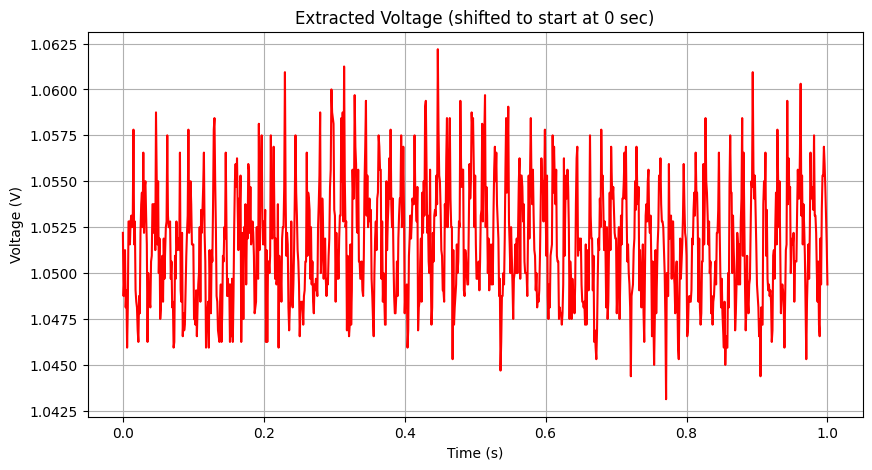

In [34]:
df_filtered = filter_time_range(df, time_range, shift_to_zero=shift_time_to_zero)

# ?? local_path?? ?? ?? ? ?? ??? ??
folder_path = os.path.dirname(local_path)
original_filename = os.path.basename(local_path)
filtered_file_name = f"Cut_{original_filename}"
filtered_file_path = os.path.join(folder_path, filtered_file_name)

save_cut_csv(df_filtered, filtered_file_path)
print(f"Filtered data saved at: {filtered_file_path}")
print(f"Rows saved: {len(df_filtered):,d}")

filtered_title = "Extracted signals"
if shift_time_to_zero:
    filtered_title += " (shifted to start at 0 sec)"

plot_multichannel_overview(
    df_filtered,
    title=filtered_title,
    ylabel="Signal",
    figsize=(10, 5),
    legend=True,
)
